# Lab 1: First Contact with Sentinel-1 over Kraków

This notebook is designed to do four things:

1. initialize the Earth Engine environment,
2. load Sentinel-1 GRD data over Kraków,
3. compare how SAR brightness changes across time,
4. some introductory .

Students should become comfortable with:

- loading satellite data in Python,
- working with an `ee.ImageCollection`,
- computing simple summary products,
- plotting histograms,
- comparing maps through time.

By the end of this notebook, students should be able to:

- explain what a Sentinel-1 image collection is,
- filter the collection to a consistent subset of scenes,
- produce a median monthly image for a given year,
- compare brightness distributions between years,
- compute a simple change metric,
- describe what they think the observed differences might represent.

---

In [1]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import datetime

print("Imports loaded.")

Imports loaded.


## 1. Initialize Google Earth Engine

This notebook assumes the Earth Engine Python API is already installed and authenticated.

If you are running this for the first time on a new machine, you may need to run:

```python
ee.Authenticate()
```

and then initialize with the project ID.

In [2]:
ee.Initialize(project="river-dynamo-494108-u6")
print("Earth Engine initialized OK.")

Earth Engine initialized OK.


## 2. Define the area of interest and some reusable settings

We use a small rectangle around Kraków.

We will work with **Sentinel-1 GRD** scenes that satisfy a consistent set of filters:

- intersect the AOI,
- same month or date range,
- IW mode,
- both VV and VH available,
- ascending orbit,
- 10 m resolution.

Using consistent filtering is important because it reduces differences caused by acquisition geometry rather than real surface change.

**Question (4 pts): Throughout this lab, we will be comparing SAR GRD level data to compare the same AOI over different periods of time. Why is it important to keep the orbit direction consistent when comparing scenes over time?**

**ANSWER:**
Because SAR satellites' radars are side-looking, and we need to make sure that we are looking at the surface from the same direction to make images comparable. Orbit direction affects the radar backscatter, shadows, layover, and how buildings or terrain slopes appear. In short, it's important to keep the geometry consistent.


In [3]:
# Area of interest: Kraków and surrounding urban/peri-urban area
aoi = ee.Geometry.Rectangle([19.85, 49.95, 20.20, 50.14])

# Analysis settings
ORBIT_PASS = "ASCENDING"
MODE = "IW"
RESOLUTION = 10

# Visualization presets
vv_vis = {"min": -20, "max": 0}
vh_vis = {"min": -28, "max": -5}

# Year range used later in the notebook
years = list(range(2015, 2025))

m = geemap.Map()
m.centerObject(aoi, 10)
m.addLayer(aoi, {"color": "red"}, "AOI")
display(m)

Map(center=[50.04506888629718, 20.024999999999867], controls=(WidgetControl(options=['position', 'transparent_…

## 3. Helper functions

These functions do most of the repetitive work:

- `get_s1_collection(...)`: build a filtered Sentinel-1 collection,
- `get_monthly_median(...)`: produce a median image for a given month and year,
- `show_scene_metadata(...)`: inspect dates and metadata,
- `fixed_histogram(...)`: compute a histogram for plotting,
- `region_stats(...)`: compute simple summary statistics over the AOI.

In [4]:
def get_s1_collection(start_date, end_date, region=aoi,
                      orbit_pass=ORBIT_PASS,
                      mode=MODE,
                      resolution=RESOLUTION):
    """
    Return a filtered Sentinel-1 GRD ImageCollection.
    """
    # Build the Sentinel-1 collection, filtered to the AOI, date range,
    # acquisition mode, orbit pass, and polarisations.
    collection = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterBounds(region)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq("instrumentMode", mode))
        .filter(ee.Filter.eq("orbitProperties_pass", orbit_pass))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
        .filter(ee.Filter.eq("resolution_meters", resolution))
        .select(["VV", "VH"])
    )

    return collection

def get_s2_collection(start_date, end_date, region=aoi,
                      max_cloud=30,
                      bands=("B2", "B3", "B4", "B8", "B11", "B12"),
                      mask_clouds=True):
    """
    Return a filtered, cloud-masked, scaled Sentinel-2 L2A ImageCollection.

    Parameters
    ----------
    start_date, end_date : str
        ISO date strings, e.g. "2024-08-01".
    region : ee.Geometry
        Area of interest used for spatial filtering.
    max_cloud : int
        Maximum allowed scene-level CLOUDY_PIXEL_PERCENTAGE.
    bands : tuple of str
        Spectral bands to keep. Default covers visible, NIR, and both SWIRs
        (10 m and 20 m bands). Add "B5","B6","B7","B8A" if you want red-edge.
    mask_clouds : bool
        If True, use the SCL layer to mask cloud, cirrus, and shadow pixels
        inside each scene before returning the collection.

    Notes
    -----
    - Reflectance is rescaled from int-scaled DN to 0-1 float.
    - SCL class codes used for masking:
        3 = cloud shadow, 8 = cloud medium prob,
        9 = cloud high prob, 10 = thin cirrus.
    """
    bands = list(bands)

    def _prep(img):
        # Cloud/shadow/cirrus mask from the Scene Classification Layer.
        if mask_clouds:
            scl = img.select("SCL")
            bad = (scl.eq(3)
                   .Or(scl.eq(8))
                   .Or(scl.eq(9))
                   .Or(scl.eq(10)))
            img = img.updateMask(bad.Not())

        # Rescale reflectance to 0-1 and carry timestamp through.
        scaled = (img.select(bands)
                    .divide(10000)
                    .copyProperties(img, ["system:time_start",
                                          "CLOUDY_PIXEL_PERCENTAGE"]))
        return scaled

    collection = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
          .filterBounds(region)
          .filterDate(start_date, end_date)
          .filter(ee.Filter.lte("CLOUDY_PIXEL_PERCENTAGE", max_cloud))
          .map(_prep)
    )

    return collection

def get_monthly_median(year, month=8, region=aoi):
    """
    Return the median Sentinel-1 image for a given month and year.
    By default, this is August because it reduces seasonal variation
    and avoids snow-related complications.
    """
    start = f"{year}-{month:02d}-01"
    if month == 12:
        end = f"{year + 1}-01-01"
    else:
        end = f"{year}-{month + 1:02d}-01"

    # Get the filtered Sentinel-1 collection for this month/year
    collection = get_s1_collection(start, end, region=region)

    # Compute the median composite and clip to the AOI
    image = collection.median().clip(region)

    return image.set({
        "year": year,
        "month": month,
        "scene_count": collection.size()
    })


def show_scene_metadata(collection):
    """
    Print selected metadata for scenes in a collection.
    Useful for discussing repeat intervals and duplicate dates.
    """
    times = collection.aggregate_array("system:time_start").getInfo()
    passes = collection.aggregate_array("orbitProperties_pass").getInfo()
    platforms = collection.aggregate_array("platform_number").getInfo()
    rel_orbits = collection.aggregate_array("relativeOrbitNumber_start").getInfo()
    slice_numbers = collection.aggregate_array("sliceNumber").getInfo()
    total_slices = collection.aggregate_array("totalSlices").getInfo()
    orbit_numbers = collection.aggregate_array("orbitNumber_start").getInfo()

    print(f"{'Date':<12} | {'Pass':<10} | {'Sat':<4} | {'RelOrbit':<8} | {'Slice':<10} | {'OrbitNum':<8}")
    print("-" * 75)
    for t, p, sat, ro, sn, ts, on in zip(times, passes, platforms, rel_orbits,
                                         slice_numbers, total_slices, orbit_numbers):
        dt = datetime.datetime.fromtimestamp(t / 1000, datetime.UTC)
        slice_info = f"{sn}/{ts}"
        print(f"{str(dt.date()):<12} | {p:<10} | S1{sat:<2} | {ro:<8} | {slice_info:<10} | {on:<8}")


def fixed_histogram(image, region, band, hist_min, hist_max, n_bins=100, scale=10):
    """
    Compute a fixed histogram for one band of an Earth Engine image.
    Returns bin centers, counts, and bin width.
    """
    hist = image.select(band).reduceRegion(
        reducer=ee.Reducer.fixedHistogram(hist_min, hist_max, n_bins),
        geometry=region,
        scale=scale,
        maxPixels=1e9,
        bestEffort=True
    ).get(band)

    hist = ee.List(hist).getInfo()
    bin_edges = [row[0] for row in hist]
    counts = [row[1] for row in hist]
    bin_width = (hist_max - hist_min) / n_bins
    bin_centers = [edge + bin_width / 2 for edge in bin_edges]

    return bin_centers, counts, bin_width


def normalize_counts(counts):
    total = sum(counts)
    if total == 0:
        return counts
    return [c / total for c in counts]


def region_stats(image, region, band):
    """
    Return mean, median, std dev, and max for a selected band.
    """
    stats = image.select(band).reduceRegion(
        reducer=(
            ee.Reducer.mean()
            .combine(ee.Reducer.median(), sharedInputs=True)
            .combine(ee.Reducer.stdDev(), sharedInputs=True)
            .combine(ee.Reducer.max(), sharedInputs=True)
        ),
        geometry=region,
        scale=10,
        maxPixels=1e9,
        bestEffort=True
    ).getInfo()

    return {
        "mean": stats.get(f"{band}_mean"),
        "median": stats.get(f"{band}_median"),
        "stdDev": stats.get(f"{band}_stdDev"),
        "max": stats.get(f"{band}_max"),
    }


print("Helper functions defined.")


Helper functions defined.


## 4. Inspect one month of data in detail

This section focuses on January 2024.  
The goal is no deep interpretation yet — it is simply to inspect the collection and compare the returned GRD file, comparing the scene with your a priori knowledge of the Krakow area.

We want to return a filtered Sentinel-11 GRD ImageCollection that is filtered by:
- region
- start_date and end_date
- instrumentMode = "IW"
- transmitterReceiverPolarisation contains both "VV" and "VH"
- orbitProperties_pass = "ASCENDING"
- resolution_meters = 10

Things you might notice:
- For a given AOI, multiple slices can exist,
- one overpass can be represented by multiple scene slices,
- image collections often contain more than one product per date over the AOI.



In [5]:
#YOU WILL NEED TO WRITE THE get_s1_collection FUNCTION TO GET THIS TO WORK. ONCE YOU HAVE
#THE FUNCTION WORKING, PLACE IT IN THE FUNCTIONS CODE BLOCK IN SECTION 3.
jan_2024 = get_s1_collection("2024-01-01", "2024-02-01", region=aoi)

#YOU WILL NEED TO ADAPT THE show_scene_metadata() FUNCTION TO ANSWER THE QUESTION BELOW
print("Image count:", jan_2024.size().getInfo())
show_scene_metadata(jan_2024)

jan_2024_img = jan_2024.median().clip(aoi)

m = geemap.Map()
m.centerObject(aoi, 10)

#If we were plotting just one img, you would simply use the line below. A split_map allows
#two scenes to be compared via a slider bar.
#m.addLayer(jan_2024_img.select("VV"), vv_vis, "VV January 2024")

m.split_map(
    left_layer=geemap.ee_tile_layer(jan_2024_img.select("VV"), vv_vis, "VV January 2024"),
    right_layer=geemap.ee_tile_layer(jan_2024_img.select("VH"), vh_vis, "VH January 2024")
)
display(m)

Image count: 10
Date         | Pass       | Sat  | RelOrbit | Slice      | OrbitNum
---------------------------------------------------------------------------
2024-01-05   | ASCENDING  | S1A  | 102      | 13/29      | 51974   
2024-01-05   | ASCENDING  | S1A  | 102      | 14/29      | 51974   
2024-01-10   | ASCENDING  | S1A  | 175      | 13/29      | 52047   
2024-01-10   | ASCENDING  | S1A  | 175      | 14/29      | 52047   
2024-01-17   | ASCENDING  | S1A  | 102      | 13/29      | 52149   
2024-01-17   | ASCENDING  | S1A  | 102      | 14/29      | 52149   
2024-01-22   | ASCENDING  | S1A  | 175      | 13/29      | 52222   
2024-01-22   | ASCENDING  | S1A  | 175      | 14/29      | 52222   
2024-01-29   | ASCENDING  | S1A  | 102      | 13/29      | 52324   
2024-01-29   | ASCENDING  | S1A  | 102      | 14/29      | 52324   


Map(center=[50.04506888629718, 20.024999999999867], controls=(ZoomControl(options=['position', 'zoom_in_text',…

**QUESTION (4 pts): We know Sentinel-1 has an approximately 6-day repeat time. However, from the metadata presented above, there are 10 images that GEE grabbed, two for each acquisition day. Why is that? Do not guess, look into the metadata for those scenes to get your answer. You will need to modify the metadata function in the helper functions code block above. Please also adjust the print function to print the metadata field you thinks supports your answer**

Some common metadata fields are:`time_start`, `platform_number`, `orbitProperties_pass`, `relativeOrbitNumber_start`, `sliceNumber`, `totalSlices`, `instrumentMode`, `transmitterReceiverPolarisation`, `resolution_meters`, and `orbitNumber_start`. 

**ANSWER:**
GEE returned two images per acquisition day because the AOI intersects two adjacent Sentinel-1 slices. The supporting metadata is sliceNumber, which shows slices 13/29 and 14/29 for the same date, same orbit number, same relative orbit, same satellite, and same pass direction. Therefore, the duplicate dates are caused by slicing of the same acquisition, not by separate satellite passes.

## 5. Compare early and recent August composites

For the first change-oriented comparison, we use one August composite near the beginning and one near the end of the analysis period.

Why August?
- it helps keep the seasonal window consistent,
- it avoids winter snow issues,
- it gives a cleaner year-to-year comparison.

Why not August?
- Vegetative growth may impact radar returns (e.g., depending on the conditions earlier in the summer, foliage may be at a different growth level

> **If you are curious:**  
> Once you have finished the lab, you can change the month from August to January or April (or any of your choice) and describe how the maps, histograms, or time series plots differ. Maybe another month would be a better choice?


In [6]:
# Build one August median image for every year
images_by_year = {year: get_monthly_median(year, month=8, region=aoi) for year in years}

first_year = years[0]
last_year = years[-1]

img_first = images_by_year[first_year]
img_last = images_by_year[last_year]

m = geemap.Map()
m.centerObject(aoi, 11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_first.select("VV"), vv_vis, f"VV {first_year}"),
    right_layer=geemap.ee_tile_layer(img_last.select("VV"), vv_vis, f"VV {last_year}")
)
display(m)

Map(center=[50.04506888629718, 20.024999999999867], controls=(ZoomControl(options=['position', 'zoom_in_text',…

**QUESTION (8 pts): Compare the 2015 and 2025 median maps carefully.** 

- Start with the old town. Do you notice much change? Why do you think that is?
- Find an area that has significant change in bright pixels. What does this represent?
- What about the darkest pixels?
- Pixels or groups of pixels that are consistently bright across many years are excellent candidates for 
      the persistent scatterer, which we will cover in a later lab. What features do you think might make 
      excellent candidates for persistent scatterer analysis? 

**ANSWER:**
- In the old town, there is not much change in the median VV image. This makes sense because there is no much buildup change in the area. The only thing is that the 2015 image looks a bit brighter, but that might be caused by the different acquisition dates.
- There is a large area of bright pixels in the 2024 image near Górka Narodowa. It's because the area was used for development of suburban housing estates.
- Darkest pixels stay mostly the same, since those are rivers and water bodies. They are mostly static over the years.
- Old town is a good candidate for persistent scatterer analysis, since it's mostly static over the years and bright.


## 6. Histogram comparison of VV brightness

A histogram is a simple way to summarize the distribution of pixel brightness values over the AOI.

Here we compare the VV histograms for the first and last August composites.

This is useful because a map can be visually overwhelming, while a histogram can show whether:
- the distribution shifts,
- the bright tail changes,
- one year has more bright scatterers than another.

>Important note:
A histogram of the whole AOI is a blunt tool. If the signal is subtle, the result may be hard to interpret. That is okay — part of the lesson is learning that some analyses are more sensitive than others.

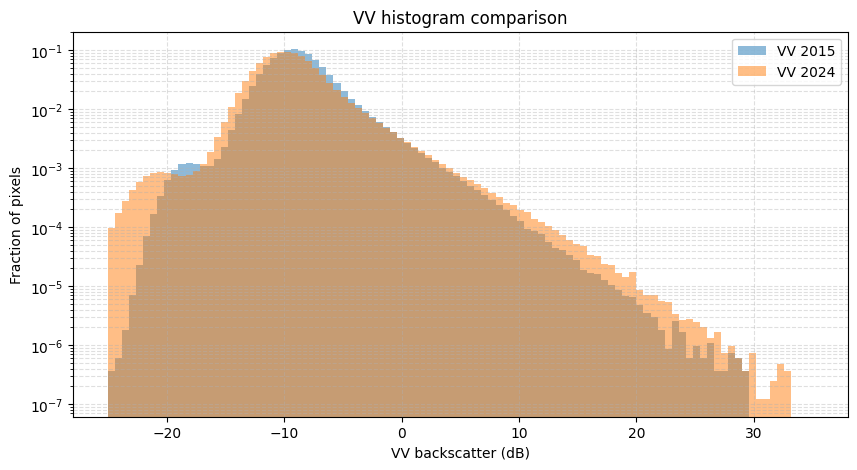

2015 VV stats: {'mean': -8.67223122960943, 'median': -8.875194515916215, 'stdDev': 3.06930373459068, 'max': 29.39563219751134}
2024 VV stats: {'mean': -9.286140736658623, 'median': -9.750873222813965, 'stdDev': 3.426506464939447, 'max': 33.13410592782661}


In [7]:
# Histogram settings
vv_hist_min = -25
vv_hist_max = 35
vv_hist_bins = 100

x1, y1, bw1 = fixed_histogram(img_first, aoi, band="VV",
                              hist_min=vv_hist_min, hist_max=vv_hist_max,
                              n_bins=vv_hist_bins)
x2, y2, bw2 = fixed_histogram(img_last, aoi, band="VV",
                              hist_min=vv_hist_min, hist_max=vv_hist_max,
                              n_bins=vv_hist_bins)

y1n = normalize_counts(y1)
y2n = normalize_counts(y2)

plt.figure(figsize=(10, 5))
plt.bar(x1, y1n, width=bw1, alpha=0.5, label=f"VV {first_year}")
plt.bar(x2, y2n, width=bw2, alpha=0.5, label=f"VV {last_year}")
plt.xlabel("VV backscatter (dB)")
plt.ylabel("Fraction of pixels")
plt.title("VV histogram comparison")
plt.yscale("log")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.show()

stats_first = region_stats(img_first, aoi, "VV")
stats_last = region_stats(img_last, aoi, "VV")

print(f"{first_year} VV stats:", stats_first)
print(f"{last_year} VV stats:", stats_last)

**QUESTION (4 pts): What do you notice about the distribution on the bright side tail of the distribution of pixel brightness? Discuss both the number of bright pixels and their distribution, and what each represents. ADJUST THE X-AXIS IN THE CODE TO GRAB THE PART OF THE HISTOGRAM THAT SUPPORTS YOUR ANSWER BELOW**

**ANSWER:**
The 2024 histogram has more pixels in the bright-side tail, meaning that a larger fraction of the AOI has high SAR backscatter. These bright pixels likely represent strongly reflecting urban surfaces such as buildings, roads, and other built structures, so the increase is consistent with urban development. The bright tail also extends/spreads into higher brightness values, suggesting not only more bright pixels, but also more very strong reflectors, which may indicate denser or more complex built-up areas.

## 7. Compute a simple SAR ratio image: VV - VH

A very simple and common calculation is the difference between the VV and VH bands:

\[
VV - VH
\]

This is not a full physical interpretation yet, but it is a useful derived quantity because it often separates surface types better than VV or VH alone. We will cover polarimetric SAR in later labs and lectures,
but the important thing to know here is that VV returns most strongly come from hard surface reflectors, things
like buildings, bridges, and roads, while VH returns most strongly come from distributed or volumetric scattering,
for example by bouncing many times in vegetative growth before returning to the satellite.

Here we compare the ratio-like image `VV - VH` for the first and last August composites.

To do this, select the VV band of the first image, subtract the VH band of the first image, then rename the result "VVVH" Then, do the same for the last image. Then, plot this as a split_map centered on the AOI.


In [8]:

# --- VV - VH (dB) for the first and last August composites ---
# In dB space, subtraction is equivalent to the VV/VH ratio in linear units.
ratio_first = (
    img_first.select("VV")
             .subtract(img_first.select("VH"))
             .rename("VVVH")
)

ratio_last = (
    img_last.select("VV")
            .subtract(img_last.select("VH"))
            .rename("VVVH")
)

# Visualisation preset for the ratio image.
# Bright pixels  -> surface/double-bounce scatterers (buildings, bare ground)
# Dark pixels    -> volumetric scatterers (vegetation)
ratio_vis = {"min": 0, "max": 15, "palette": ["black", "white"]}

# Side-by-side comparison of the first and last August composites.
m = geemap.Map()
m.centerObject(aoi, 11)
m.split_map(
    left_layer=geemap.ee_tile_layer(
        ratio_first, ratio_vis, f"VV-VH {first_year}"
    ),
    right_layer=geemap.ee_tile_layer(
        ratio_last, ratio_vis, f"VV-VH {last_year}"
    ),
)
display(m)

Map(center=[50.04506888629718, 20.024999999999867], controls=(ZoomControl(options=['position', 'zoom_in_text',…

**QUESTION (4 pts): Where do you notice the biggest changes in the VV-VH ratio. Focus not only on the largest increases, but also the largest decreases. In doing so, are we making a qualitative or quantitative assesment?**

**ANSWER:**
The largest increase in the VV-VH ratio that I noticed is near the eastern/right side of the AOI, around the MAN Trucks Sp. z o.o. area near Niepołomice. This area appears much brighter in 2024 than in 2015, suggesting that VV backscatter increased relative to VH. This is consistent with industrial development, because large buildings, paved surfaces, and other infrastructure can create stronger radar returns, especially in VV. I also notice a decrease in the VV-VH ratio in northwest Kraków, around the Bronowice area. This darker change may mean that VV became weaker relative to VH, or that VH increased relative to VV. One possible explanation is an increase in trees or vegetation, since vegetation often contributes more to VH/volume scattering. Since these changes are identified visually from the map rather than by measuring exact pixel values, this is mainly a qualitative assessment.


## 8. Visualize change in VV - VH

Now we map the difference:

\[
(VV - VH)_{last} - (VV - VH)_{first}
\]

Positive values indicate an increase in this quantity through time, while negative values indicate a decrease.

At this stage, you should not over-interpret the result. The correct first step is simply to identify:
- where change appears strongest,
- whether it is spatially clustered,
- whether it seems plausible.



In [9]:
# Visualization presets
change_vis = {"min": -3, "max": 3, "palette": ["blue", "white", "red"]}

aoi_blue = ee.Geometry.Rectangle([19.85, 49.95, 20.20, 50.14])

ratio_change = ratio_last.subtract(ratio_first).rename("dVVVH")

m2 = geemap.Map()
m2.centerObject(aoi, 11)
m2.addLayer(aoi, {"color": "red"}, "AOI")
m2.addLayer(ratio_change, change_vis, "Change in VV-VH")
display(m2)

Map(center=[50.04506888629718, 20.024999999999867], controls=(WidgetControl(options=['position', 'transparent_…

**QUESTION (4 pts): Investigate this change map carefully.** 

- First, identify an area that had a large scale increase in this ratio. Why did VV increase relative to VH in this area?
- Second, I want you to find the area in the top right of the map that had a significant decrease in VV/VH. You can use the code block below to highlight where it is. Using optical data (google maps is fine here), tell me what that feature is. Why do you think it may have had strong VV in 2015, and strong VH in 2025, even though they were both taken in August?**

`aoi_blue = ee.Geometry.Rectangle([19.85, 49.95, 20.20, 50.14])`

`m2.addLayer(aoi, {"color": "red"}, "AOI")`

**ANSWER:**

- Same as before, there is an area near Niepołomice, MAN Trucks buildins area, that has the biggest increase in a VV-VH ratio. But also, there is a road built on the top on the map, which also can be noticed by a strong increase in a VV-VH ratio.
- The significant decrease in VV-VH in the top-right of the map appears to be agricultural land. In 2015 it may have been bare or harvested, giving relatively strong VV, while in 2024/2025 it may have contained crops or denser vegetation in August. Vegetation increases VH through volume scattering, so VH became stronger relative to VV and the VV-VH ratio decreased. I wasn't able to validate it with satellite imagery from Google Earth engine since there was no images specifically from August of both years.

## 9. Threshold-based change mask

This section turns a continuous change image into a very simple binary mask.

This is intentionally crude. The point is to show that:
- a threshold is a choice,
- different thresholds produce different maps,
- classification decisions require judgment.

The logic below flags pixels that:
- started relatively low,
- ended relatively high,
- increased by at least a chosen amount.

In [27]:
# Thresholds (all in dB). Tune these to refine the mask.
low_thresh    = 8    # ratio_first must be BELOW this (vegetation-like in 2015)
high_thresh   = 10   # ratio_last must be ABOVE this (surface-like in 2024)
change_thresh = 2    # ratio_change must have INCREASED by at least this much

#WRITE THE LOGIC TO FLAG PIXELS THAT HAVE SATISFIED THE ABOVE THRESHOLDS. USEFUL LOGIC
#FUNCTIONS INCLUDE .And(), .Or(), .lt() for less than, .gt() for greater than
transition = (
    ratio_first.lt(low_thresh)
        .And(ratio_last.gt(high_thresh))
        .And(ratio_change.gt(change_thresh))
        .rename("transition")
)

#This block will print your fraction of the AOI that you have flagged
frac = transition.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=aoi,
    scale=10,
    maxPixels=1e9
).get("transition").getInfo()

print("Fraction flagged:", frac)

m3 = geemap.Map()
m3.centerObject(aoi, 11)
m3.addLayer(img_last.select("VV"), vv_vis, f"VV {last_year}")
m3.addLayer(ratio_change, change_vis, "d(VV-VH)")
m3.addLayer(
    transition.updateMask(transition),
    {"min": 0, "max": 1, "palette": ["yellow"]},
    "Transition mask"
)
display(m3)

Fraction flagged: 0.029539312762258338


Map(center=[50.04506888629718, 20.024999999999867], controls=(WidgetControl(options=['position', 'transparent_…

**QUESTION (4 pts): Why did you choose the thresholds that you chose? Was it easy, or even possible, to arrive at a classification scheme that you think accurately captured urban development in the Krakow area?**

**ANSWER:**
I chose the thresholds based on experiments with them, and when they will cover the red areas the most. I also looked at the histogram from previous cells that showed the number of pixels with a given magnitude. It covered new road and MAN trucks facilities as expected, so I think it captured the urban and industrial development well. It wasn't that easy to find those values.


## 10. Histogram of the change image

This plot summarizes the distribution of the `VV - VH` change image.

It is useful for:
- seeing whether most pixels changed very little,
- checking whether the distribution is centered near zero,
- deciding whether the threshold values are reasonable.

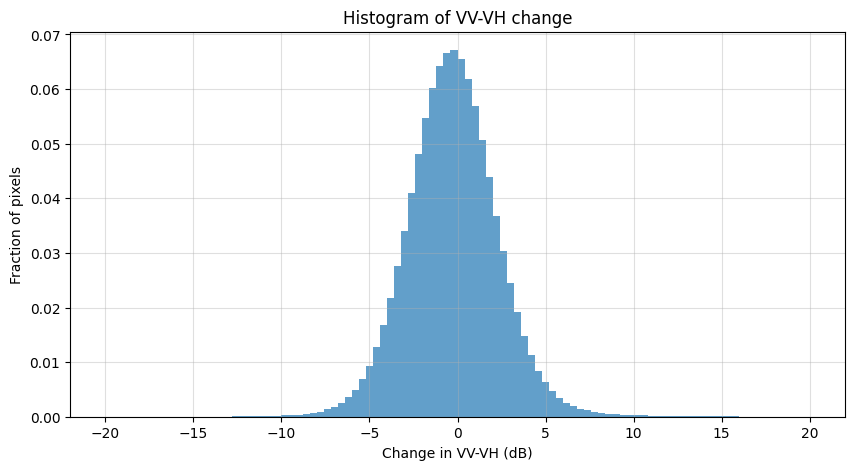

In [28]:
x_change, y_change, bw_change = fixed_histogram(
    ratio_change, aoi, "dVVVH", hist_min=-20, hist_max=20, n_bins=100
)

y_change_norm = normalize_counts(y_change)

plt.figure(figsize=(10, 5))
plt.bar(x_change, y_change_norm, width=bw_change, alpha=0.7)
plt.xlabel("Change in VV-VH (dB)")
plt.ylabel("Fraction of pixels")
plt.title("Histogram of VV-VH change")
plt.grid(True, alpha=0.4)
plt.show()

**QUESTION (4 pts):
First, notice that this histogram is not centered on 0, it is shifted slightly towards negative values. This means that VV is stronger in 2015 than in 2025! Does this go against all the analysis you just did? If this is confusing, go back to the very first split_image, comparing VV in 2015 and 2025. When we first did that, we were focused on the brightest pixels only. Now I want you to focus on the map as a whole, ignoring the brightest pixels. What can you say about the strength of VV returns in 2015 vs 2025. Thinking about what we have learned about scattering physics, what do you think might be the cause of this?**

**ANSWER:**
Whole image of VV in August 2015 is slightly brighter than the 2024 image. This can be caused by differences in environmental conditions rather than urban change alone. Wetter soil, less vegetation cover, or more bare/harvested agricultural fields in August 2015 could have increased VV backscatter across much of the AOI. In 2024, denser vegetation or drier conditions may have lowered the general VV response. Therefore, this does not fully contradict the urban-development analysis: urban growth may still produce localized new bright scatterers, while the overall AOI brightness is influenced by moisture, crops, vegetation, and acquisition-date differences.

## 11. Track a simple metric through time

Instead of comparing only two years, we can compute the same metric for every year.

Here we calculate the fraction of the AOI with:

\[
VV - VH > threshold
\]

for each August composite.

This is a very simple time-series summary. It is not a full change detection method, but it requires:
- looping over years,
- deriving one metric per image,
- plotting a time series.

,year,frac_flagged
0,2015,0.026686
1,2016,0.017477
2,2017,0.018768
3,2018,0.022492
4,2019,0.025243
5,2020,0.026361
6,2021,0.027477
7,2022,0.038199
8,2023,0.029211
9,2024,0.031171


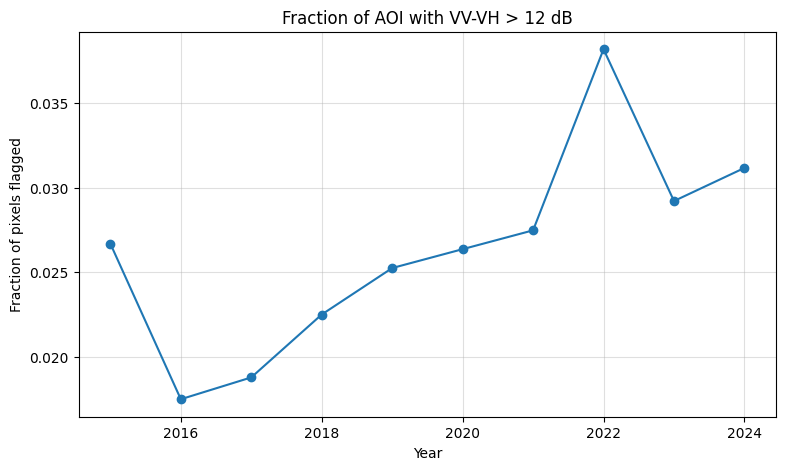

In [32]:
ratio_thresh = 12
rows = []

for year in years:
    yearly = images_by_year[year]
    ratio = yearly.select("VV").subtract(yearly.select("VH")).rename("VVVH")

    frac_flagged = ratio.gt(ratio_thresh).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=10,
        maxPixels=1e9
    ).get("VVVH").getInfo()

    rows.append({
        "year": year,
        "frac_flagged": frac_flagged
    })

df = pd.DataFrame(rows)
display(df)

plt.figure(figsize=(9, 5))
plt.plot(df["year"], df["frac_flagged"], marker="o")
plt.xlabel("Year")
plt.ylabel("Fraction of pixels flagged")
plt.title(f"Fraction of AOI with VV-VH > {ratio_thresh} dB")
plt.grid(True, alpha=0.4)
plt.show()

**QUESTION (8 pts):**

- **Why did you choose the threshold that you did?**
- **This is our first attempt to actually quantify and track a specific metric of urban development over a longer time period. Do you think the metric you arrived at accurately quantifies the amount of urban development? Or do you think the metric shows overall trends in urban development, but that there may be too many assumptions to accurately quantify this?**
- **What do you think may be happening with the outliers?**

**ANSWER:**
- I started with the threshold 10 dB because it seemed to capture a reasonable balance between sensitivity to urban development and robustness against noise. I left it as 12 dB because it also captures the urban growth well.
- I think the metric accurately quantifies urban development, but it may be sensitive to changes in vegetation, soil moisture, and other environmental factors that can affect a VV-VH ratio.
- I think the outliers might be caused by the drought that might have happened in years that seems to outlie.


## Sentinel 2 images below

In [13]:
# Cloud-masked median August composite, 2024
s2_2024 = get_s2_collection("2024-08-01", "2024-09-01", region=aoi)
s2_2024_img = s2_2024.median().clip(aoi)

# True-colour preview (bands already in 0-1 after scaling).
rgb_vis = {"min": 0.0, "max": 0.3, "bands": ["B4", "B3", "B2"]}
ndvi = s2_2024_img.normalizedDifference(["B8", "B4"]).rename("NDVI")

m_s2 = geemap.Map()
m_s2.centerObject(aoi, 11)
m_s2.addLayer(s2_2024_img, rgb_vis, "S2 RGB August 2024")
m_s2.addLayer(ndvi, {"min": 0, "max": 1, "palette": ["white", "green"]}, "NDVI 2024")
display(m_s2)

Map(center=[50.04506888629718, 20.024999999999867], controls=(WidgetControl(options=['position', 'transparent_…

In [30]:
# --- S1 vs S2 comparison: three swipeable maps ---
# Uses: get_s1_collection, get_s2_collection, get_monthly_median, aoi, vv_vis, ratio_vis
# Produces three geemap.Maps, each with a split_map slider.

COMPARE_YEAR  = last_year       # reuse the last S1 August composite year
COMPARE_MONTH = 8               # August, to match the SAR analysis

# ---- 1. Build matching composites ------------------------------------------
# S1 August median for the chosen year (reuse the dict you already have).
s1_img = images_by_year[COMPARE_YEAR].clip(aoi)

# S2 median over a slightly wider window (Jun-Sep) so we have enough
# cloud-free observations to produce a clean composite.
s2_start = f"{COMPARE_YEAR}-06-01"
s2_end   = f"{COMPARE_YEAR}-09-30"
s2_coll  = get_s2_collection(s2_start, s2_end, region=aoi, max_cloud=40)
s2_img   = s2_coll.median().clip(aoi)

print(f"S1 scenes used:  {s1_img.get('scene_count').getInfo()}")
print(f"S2 scenes used:  {s2_coll.size().getInfo()}")

# ---- 2. Derived indices ----------------------------------------------------
# S2 NDVI = (NIR - Red) / (NIR + Red)   -> vegetation vigour
s2_ndvi = s2_img.normalizedDifference(["B8", "B4"]).rename("NDVI")

# S2 NDBI = (SWIR - NIR) / (SWIR + NIR) -> built-up / bare surfaces
s2_ndbi = s2_img.normalizedDifference(["B11", "B8"]).rename("NDBI")

# S1 VV - VH (dB) -> surface- vs volume-scattering proxy (already in ratio_first / ratio_last
# style); build a fresh one tied to this single year:
s1_ratio = (s1_img.select("VV")
                  .subtract(s1_img.select("VH"))
                  .rename("VVVH"))

# ---- 3. Visualisation presets ----------------------------------------------
s2_rgb_vis  = {"bands": ["B4", "B3", "B2"], "min": 0.0,  "max": 0.3}
ndvi_vis    = {"min": 0.0,  "max": 0.8,  "palette": ["#a52a2a", "#ffffbf", "#1a9850"]}
ndbi_vis    = {"min": -0.3, "max": 0.3,  "palette": ["#2c7bb6", "#ffffbf", "#d7191c"]}

# ---- 4. Map A: S2 true colour  <->  S1 VV ---------------------------------
mA = geemap.Map()
mA.centerObject(aoi, 11)
mA.split_map(
    left_layer=geemap.ee_tile_layer(
        s2_img, s2_rgb_vis, f"S2 RGB {COMPARE_YEAR}"
    ),
    right_layer=geemap.ee_tile_layer(
        s1_img.select("VV"), vv_vis, f"S1 VV {COMPARE_YEAR}"
    ),
)
print("Map A: S2 true colour  <->  S1 VV backscatter")
display(mA)

# ---- 5. Map B: S2 NDVI  <->  S1 VV-VH -------------------------------------
mB = geemap.Map()
mB.centerObject(aoi, 11)
mB.split_map(
    left_layer=geemap.ee_tile_layer(
        s2_ndvi, ndvi_vis, f"S2 NDVI {COMPARE_YEAR}"
    ),
    right_layer=geemap.ee_tile_layer(
        s1_ratio, ratio_vis, f"S1 VV-VH {COMPARE_YEAR}"
    ),
)
print("Map B: S2 NDVI  <->  S1 VV-VH ratio")
display(mB)

# ---- 6. Map C: S2 NDBI  <->  S1 VV ----------------------------------------
mC = geemap.Map()
mC.centerObject(aoi, 11)
mC.split_map(
    left_layer=geemap.ee_tile_layer(
        s2_ndbi, ndbi_vis, f"S2 NDBI {COMPARE_YEAR}"
    ),
    right_layer=geemap.ee_tile_layer(
        s1_img.select("VV"), vv_vis, f"S1 VV {COMPARE_YEAR}"
    ),
)
print("Map C: S2 NDBI (built-up)  <->  S1 VV backscatter")
display(mC)

S1 scenes used:  10
S2 scenes used:  17
Map A: S2 true colour  <->  S1 VV backscatter


Map(center=[50.04506888629718, 20.024999999999867], controls=(ZoomControl(options=['position', 'zoom_in_text',…

Map B: S2 NDVI  <->  S1 VV-VH ratio


Map(center=[50.04506888629718, 20.024999999999867], controls=(ZoomControl(options=['position', 'zoom_in_text',…

Map C: S2 NDBI (built-up)  <->  S1 VV backscatter


Map(center=[50.04506888629718, 20.024999999999867], controls=(ZoomControl(options=['position', 'zoom_in_text',…